### Installations

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn great-tables matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


### Table 2 | Reliability of PARK Predictions Compared to PD Specialists

In [2]:
import sys
import pandas as pd
import numpy as np
from great_tables import GT, style, loc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df = pd.read_csv('../../data/test_data_big.csv')

df = df.dropna(subset=['neurologist_label_ray', 'neurologist_label_ruth', 'neurologist_label_jamie'])
assert len(df) == 30, f"Expected 30 rows, but got {len(df)}"

true_labels = df['true_label'].astype(int)

predictions = {
    "Specialist 1": df['neurologist_label_ray'].astype(int),
    "Specialist 2": df['neurologist_label_ruth'].astype(int),
    "Specialist 3": df['neurologist_label_jamie'].astype(int),
    "PARK": (df['pred_score_fusion'] >= 0.5).astype(int)
}


def bootstrap_metrics(y_true, y_pred, b=1000):
    n = len(y_true)
    metrics = {
        "accuracy": [],
        "specificity": [],
        "sensitivity": [],
        "ppv": [],
        "npv": [],
        "f1_score": []
    }
    
    for j in range(b):
        idxs = np.random.choice(n, n, replace=True)
        y_true_sample = y_true.iloc[idxs]
        y_pred_sample = y_pred.iloc[idxs]

        if(np.sum(np.asarray(y_true_sample))==0 or np.sum(~np.asarray(y_true_sample))==0 or np.sum(np.asarray(y_pred_sample))==0 or np.sum(~np.asarray(y_pred_sample))==0):
            print(y_true_sample)
            print(y_pred_sample)
            j = j-1
            continue
            
        tn, fp, fn, tp = confusion_matrix(y_true_sample, y_pred_sample, labels=[0,1]).ravel()
        
        acc = accuracy_score(y_true_sample, y_pred_sample)
        sens = recall_score(y_true_sample, y_pred_sample)
        spec = tn / (tn + fp) if (tn + fp) != 0 else 0
        ppv_val = precision_score(y_true_sample, y_pred_sample)
        npv_val = tn / (tn + fn) if (tn + fn) != 0 else 0
        f1 = f1_score(y_true_sample, y_pred_sample)
        
        metrics["accuracy"].append(acc)
        metrics["specificity"].append(spec)
        metrics["sensitivity"].append(sens)
        metrics["ppv"].append(ppv_val)
        metrics["npv"].append(npv_val)
        metrics["f1_score"].append(f1)
    
    results = {}
    for key in metrics.keys():
        mean = np.mean(metrics[key])
        std = np.std(metrics[key], ddof=1)
        ci = 1.96 * std
        results[key] = (mean, ci)
    
    return results


model_results = {}
for model_name, preds in predictions.items():
    model_results[model_name] = bootstrap_metrics(true_labels, preds)

data = {
    "Model": [],
    "Accuracy": [],
    "Specificity": [],
    "Sensitivity": [],
    "PPV": [],
    "NPV": [],
    "F1 Score": []
}

for model_name, results in model_results.items():
    data["Model"].append(model_name)
    data["Accuracy"].append(f"{results['accuracy'][0]*100:.1f}% ±{results['accuracy'][1]*100:.1f}%")
    data["Specificity"].append(f"{results['specificity'][0]*100:.1f}% ±{results['specificity'][1]*100:.1f}%")
    data["Sensitivity"].append(f"{results['sensitivity'][0]*100:.1f}% ±{results['sensitivity'][1]*100:.1f}%")
    data["PPV"].append(f"{results['ppv'][0]*100:.1f}% ±{results['ppv'][1]*100:.1f}%")
    data["NPV"].append(f"{results['npv'][0]*100:.1f}% ±{results['npv'][1]*100:.1f}%")
    data["F1 Score"].append(f"{results['f1_score'][0]*100:.1f}% ±{results['f1_score'][1]*100:.1f}%")

df_metrics = pd.DataFrame(data)

In [4]:
df_metrics

,Model,Accuracy,Specificity,Sensitivity,PPV,NPV,F1 Score
0,Specialist 1,80.1% ±14.5%,36.5% ±35.2%,95.7% ±8.4%,80.8% ±15.1%,74.2% ±50.5%,87.4% ±10.1%
1,Specialist 2,86.8% ±12.3%,63.3% ±35.1%,95.3% ±9.1%,87.7% ±13.4%,83.4% ±33.3%,91.2% ±9.0%
2,Specialist 3,76.7% ±15.1%,75.2% ±32.8%,77.1% ±17.3%,89.5% ±14.1%,54.6% ±29.8%,82.5% ±12.7%
3,PARK,83.5% ±13.3%,75.5% ±31.6%,86.4% ±14.6%,90.8% ±12.1%,66.9% ±32.3%,88.3% ±10.3%


In [5]:
import re

metric_cols = df_metrics.columns[1:]

def to_two_line_cell(s):
    """
    Convert '80.3% ±14.0%' into:
    \\begin{tabular}[c]{@{}c@{}}80.3\\%\\\\$\\pm$ 14.0\\%\\end{tabular}
    """
    if pd.isna(s):
        return ""

    s = str(s).strip()

    # Match patterns like: 80.3% ±14.0%
    m = re.match(r"^\s*([0-9.]+)\s*%\s*±\s*([0-9.]+)\s*%\s*$", s)
    if m:
        mean = m.group(1)
        err = m.group(2)
        return rf"\begin{{tabular}}[c]{{@{{}}c@{{}}}}{mean}\%\\$\pm$ {err}\%\end{{tabular}}"

    return s

# Format metric columns
df_latex = df_metrics.copy()

for col in metric_cols:
    df_latex[col] = df_latex[col].apply(to_two_line_cell)

df_latex.to_latex("./tables/comparison_specialists_park.tex", index=False, bold_rows=True, caption="X", label="tab:clinical_metrics_comparison", position="htbp")


In [6]:
# def split_metric_ci(value):
#     metric, ci = value.split(' ')
#     return f"{metric}<br>{ci}"

# metric_columns = ["Accuracy", "Specificity", "Sensitivity", "PPV", "NPV", "F1 Score"]
# for col in metric_columns:
#     df_metrics[col] = df_metrics[col].apply(split_metric_ci)


In [7]:
# gt = GT(df_metrics)

# palette = [
#     (255, 255, 255),  # white
#     (0, 180, 216)     # blue
# ]

# def interpolate_color(value, palette=palette):
#     value = max(0, min(1, value))
    
#     t = value 
#     r1, g1, b1 = palette[0]
#     r2, g2, b2 = palette[1]
#     r = int(r1 + (r2 - r1) * t)
#     g = int(g1 + (g2 - g1) * t)
#     b = int(b1 + (b2 - b1) * t)
   
#     return f"rgb({r},{g},{b})"

# for col in metric_columns:
#     numeric_values = df_metrics[col].apply(lambda x: float(x.split('%')[0]))
#     max_value = 100
#     min_value = 30
#     normalized = (numeric_values - min_value) / (max_value - min_value)
#     colors = normalized.apply(interpolate_color)
#     for idx, color in enumerate(colors):
#         gt = gt.tab_style(
#             style=style.fill(color=color),
#             locations=loc.body(columns=col, rows=idx)
#         )

# gt = (
#     gt.tab_stub(rowname_col="Model")
#     .tab_stubhead(label="")
#     .cols_align(align="center", columns=metric_columns)
#     .cols_align(align="left", columns="Model")
#     .opt_table_font(font="Arial")
#     .opt_vertical_padding(2)
#     .opt_horizontal_padding(3)
#     .tab_style(
#         style=style.text(color="black", weight="bold"),
#         locations=loc.column_labels()
#     )
#     .tab_style(
#         style=style.text(color="blue"),
#         locations=loc.stub()
#     )
# )

# gt.show()

In [8]:
# gt.save(file="plots/figure_3/park_clinician_comparison.png", scale=2)

### Fig 3 | Confusion Matrix of Agreement Among PD Specialists and Park 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv('../../data/test_data_big.csv')
df = df.dropna(subset=['neurologist_label_ray', 'neurologist_label_ruth', 'neurologist_label_jamie'])
assert len(df) == 30, f"Expected 30 rows, but got {len(df)}"

true_labels = df['true_label'].astype(int).values
predictions = {
    'PARK': np.where(df['pred_score_fusion'] > 0.5, 1, 0), 
    'Specialist 1': df['neurologist_label_ray'].astype(int).values,
    'Specialist 2': df['neurologist_label_ruth'].astype(int).values,
    'Specialist 3': df['neurologist_label_jamie'].astype(int).values,
    'Ground Truth': true_labels
}

# List of entity names (order matters for plotting)
entities = list(predictions.keys())

colors = ["#ade8f4", "#0077b6"]
custom_cmap = LinearSegmentedColormap.from_list("white_to_blue", colors)

def plot_conf_matrix(ax, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    #sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, cbar=False, ax=ax, square=True,
    #            xticklabels=False, yticklabels=False, annot_kws={"size": 20, "weight": 'normal'})
    sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, cbar=False, ax=ax, square=False,
                xticklabels=False, yticklabels=False, annot_kws={"size": 20, "weight": 'normal'})
                
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

# Calculate agreement rate and Cohen's kappa
def calculate_metrics(y_true, y_pred):
    agreement = np.mean(y_true == y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    return agreement, kappa

comparisons = [
    ("Specialist vs Ground Truth", ['Specialist 1', 'Specialist 2', 'Specialist 3'], 'Ground Truth'),
    ("Specialist vs Specialist", ['Specialist 1', 'Specialist 2', 'Specialist 3'], ['Specialist 1', 'Specialist 2', 'Specialist 3']),
    ("Specialist vs PARK", ['Specialist 1', 'Specialist 2', 'Specialist 3'], 'PARK'),
    ("PARK vs Ground Truth", 'PARK', 'Ground Truth')
]

table_data = []
for title, group1, group2 in comparisons:
    if isinstance(group1, list) and isinstance(group2, list):
        # Specialist vs Specialist
        agreement_rates = []
        kappa_scores = []
        for g1 in group1:
            for g2 in group2:
                if g1 != g2:
                    y_true = predictions[g1]
                    y_pred = predictions[g2]
                    agreement, kappa = calculate_metrics(y_true, y_pred)
                    agreement_rates.append(agreement)
                    kappa_scores.append(kappa)
        avg_agreement = np.mean(agreement_rates)
        avg_kappa = np.mean(kappa_scores)
        table_data.append((title, avg_agreement, avg_kappa))
    elif isinstance(group1, list):
        # Specialist vs Ground Truth or PARK
        agreement_rates = []
        kappa_scores = []
        for g in group1:
            y_true = predictions[g]
            y_pred = predictions[group2]
            agreement, kappa = calculate_metrics(y_true, y_pred)
            agreement_rates.append(agreement)
            kappa_scores.append(kappa)
        avg_agreement = np.mean(agreement_rates)
        avg_kappa = np.mean(kappa_scores)
        table_data.append((title, avg_agreement, avg_kappa))
    else:
        # PARK vs Ground Truth
        y_true = predictions[group1]
        y_pred = predictions[group2]
        agreement, kappa = calculate_metrics(y_true, y_pred)
        table_data.append((title, agreement, kappa))


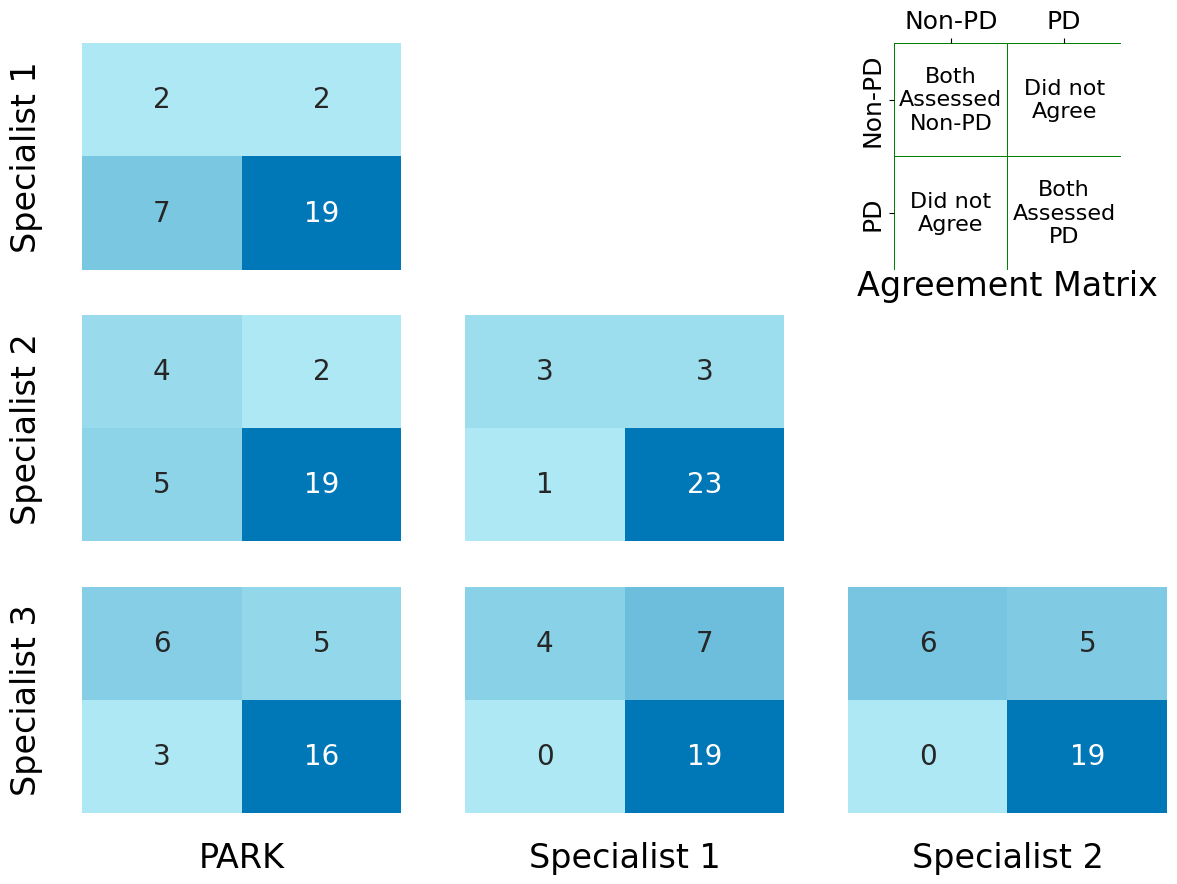

In [10]:
# --- Plotting ---

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 3)  # 3 rows, 6 columns

highlight_cells = [(0, 0), (1, 1), (2, 2)]
conf_matrix_axes = []
for i in range(3):
    row_axes = []
    for j in range(3):
        subplot = fig.add_subplot(gs[i, j])

        # subplot.axis('off')  # hide ticks/labels
        # subplot.spines['top'].set_visible(True)
        # subplot.spines['left'].set_visible(True)
        # subplot.spines['left'].set_edgecolor('red')

        row_axes.append(subplot)
    conf_matrix_axes.append(row_axes)

for i in range(3):
    for j in range(3):
        conf_matrix_axes[i][j].axis('off')

for i in range(1, 4):
    for j in range(i):
        y_true = predictions[entities[i]]
        y_pred = predictions[entities[j]]
        ax = conf_matrix_axes[i - 1][j]
        ax.axis('on')
        plot_conf_matrix(ax, y_true, y_pred)

for i in range(3):
    conf_matrix_axes[i][0].set_ylabel(entities[i + 1], rotation=90, labelpad=40, fontsize=24, va='center')

for j in range(3):
    conf_matrix_axes[2][j].set_xlabel(entities[j], fontsize=24, labelpad=20)

# #table_ax = fig.add_subplot(gs[1:2, 2:])
# table_ax = fig.add_subplot(gs[0:1, 1:3])
# table_ax.axis('off')

# table = table_ax.table(cellText=[["Evaluators", "Agreement", "Cohen's κ"]] + 
#                       [[f"{row[0]}", f"{row[1]:.3f}", f"{row[2]:.3f}"] for row in table_data],
#                       loc='center',
#                       cellLoc='center',
#                       colWidths=[0.45, 0.2, 0.2],
#                       bbox=[0, 0, 1, 1]) 

# for (i, j), cell in table.get_celld().items():
#     if j == 0:  # First column
#         cell.set_text_props(ha='left', x=0.01)  
#     if i == 0:  # Header row
#         cell.set_facecolor('#0077b6')  # Blue header
#         cell.set_text_props(color='white', weight='bold')

# for i in range(1, len(table_data) + 1):
#     if i % 2 == 0:  # Even rows
#         for j in range(3):
#             table.get_celld()[(i, j)].set_facecolor('#ade8f4')  # Light blue
#     else:  # Odd rows
#         for j in range(3):
#             table.get_celld()[(i, j)].set_facecolor('#e2fdff')  # Lighter blue

# table.auto_set_font_size(False)
# table.set_fontsize(18)
# table.scale(1, 2) 


# Legend confusion matrix
legend_ax = fig.add_subplot(gs[0,2])  
legend_ax.axis('on') 
legend_ax.set_xticks([0, 1])
legend_ax.set_yticks([0, 1])
legend_ax.set_xticklabels(['Pred 0', 'Pred 1'])
legend_ax.set_yticklabels(['True 0', 'True 1'])
legend_ax.xaxis.set_ticks_position('top')
legend_ax.xaxis.set_label_position('top')

#legend_cm = np.array([[50, 10], [8, 32]])
legend_cm = np.array([[1, 0], [0, 1]])

sns.heatmap(
    legend_cm,
    annot=[['Both\nAssessed\nNon-PD', 'Did not\nAgree'], ['Did not\nAgree', 'Both\nAssessed\nPD']],
    fmt='',
    #cmap=['red','green'],
    cmap=['White'],
    # vmin=0.25,
    # vmax=0.75,
    cbar=False,
    linewidths=0.5,
    linecolor='green',
    square=True,
    ax=legend_ax,
    annot_kws={"size": 16, "weight": 'normal', "color": 'black'}
)

legend_ax.set_xlabel('')
legend_ax.set_ylabel('')
legend_ax.set_xticklabels(['Non-PD', 'PD'], fontsize=18)
legend_ax.set_yticklabels(['Non-PD', 'PD'], fontsize=18)
legend_ax.set_title('Agreement Matrix', fontsize=24, y=-0.15)


#plt.tight_layout()
plt.savefig("plots/figure_3/clinician_agreement.png", dpi=600, bbox_inches='tight')

## Fig 5a | Accuracy of PARK Compared to Accuracy of Task-Specific Models

In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles

df = pd.read_csv('../../data/test_data_big.csv')

correct_smile = ~df['misclassified_smile']
correct_speech = ~df['misclassified_speech']
correct_finger = ~df['misclassified_finger']
correct_fusion = ~df['misclassified_fusion']

masks = {
    '100': correct_smile & ~correct_speech & ~correct_finger,
    '010': ~correct_smile & correct_speech & ~correct_finger,
    '001': ~correct_smile & ~correct_speech & correct_finger,
    '110': correct_smile & correct_speech & ~correct_finger,
    '101': correct_smile & ~correct_speech & correct_finger,
    '011': ~correct_smile & correct_speech & correct_finger,
    '111': correct_smile & correct_speech & correct_finger,
    '000': ~correct_smile & ~correct_speech & ~correct_finger 
}


# correct samples per region
subsets = {k: v.sum() for k, v in masks.items()}

def bootstrap_metrics(y_correct, b=1000):
    n = len(y_correct)
    metrics = {"accuracy": []}
    
    for _ in range(b):
        idxs = np.random.choice(n, n, replace=True)
        
        y_correct_sample = y_correct.iloc[idxs]
        acc = np.mean(y_correct_sample)
        metrics["accuracy"].append(acc)
    
    results = {}
    for key in metrics.keys():
        mean = np.mean(metrics[key])
        std = np.std(metrics[key])
        ci = 1.96 * std  
        results[key] = (mean, ci)
    
    return results


fusion_results = {}
for key, mask in masks.items():
    results = bootstrap_metrics(~df.loc[mask, 'misclassified_fusion'])
    if mask.sum() > 0:
        fusion_results[key] = results['accuracy']
    else:
        fusion_results[key] = (np.nan, np.nan)

subsets: {'100': np.int64(21), '010': np.int64(24), '001': np.int64(17), '110': np.int64(56), '101': np.int64(31), '011': np.int64(28), '111': np.int64(132), '000': np.int64(11)}


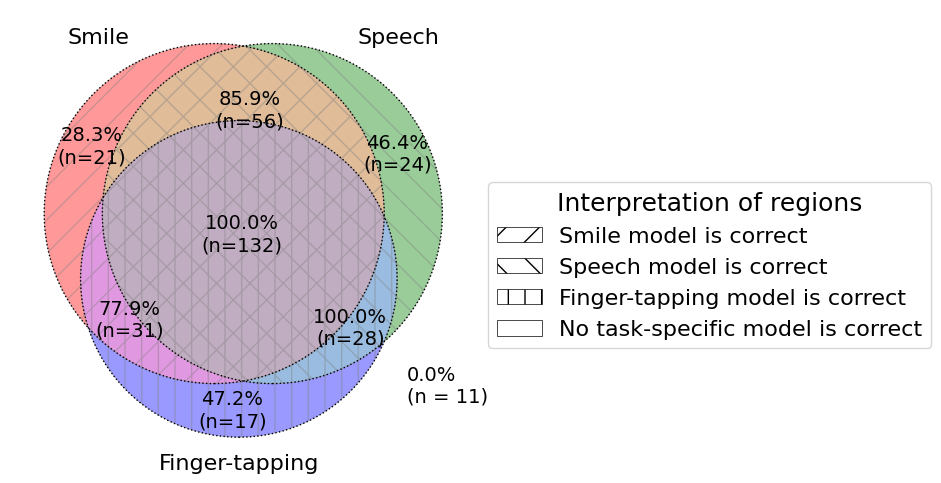

In [13]:
from matplotlib.patches import Patch
import os

def accuracy_to_color(acc):
    if np.isnan(acc):
        return (0.9, 0.9, 1.0)  # very light green for NaN
    intensity = 1.0 - 0.7 * acc
    return (intensity, 1.0, 0.5)

print(f'subsets: {subsets}')
plt.figure(figsize=(10,6))  
v = venn3(subsets=(subsets['100'], subsets['010'], subsets['110'],
                   subsets['001'], subsets['101'], subsets['011'],
                   subsets['111']),
          set_labels=('Smile', 'Speech', 'Finger-tapping'))

c = venn3_circles(subsets=(subsets['100'], subsets['010'], subsets['110'],
                            subsets['001'], subsets['101'], subsets['011'],
                            subsets['111']), linestyle='dotted')

hatch_patterns = {
    '100': '/',     # A only
    '010': '\\',    # B only
    '110': '/\\',   # A & B
    '001': '|',     # C only
    '101': '/|',    # A & C
    '011': '\\|',   # B & C
    '111': '/\\|'   # A & B & C
}

hatch_labels = {
    '000': 'No task-specific model is correct',
    '100': 'Smile model is correct',     # A only
    '010': 'Speech model is correct',    # B only
    '110': 'Smile and speech models are correct, finger model is incorrect',   # A & B
    '001': 'Finger-tapping model is correct',     # C only
    '101': 'Smile and finger models are correct, speech model is incorrect',    # A & C
    '011': 'Speech and finger models are correct, smile model is incorrect',   # B & C
    '111': 'All task-specific models are correct'   # A & B & C
}

# Apply hatches and prepare legend entries
legend_handles = []

# Apply hatching to each subset
for region_id in hatch_patterns.keys():
    patch = v.get_patch_by_id(region_id)
    patch.set_hatch(hatch_patterns[region_id])
    patch.set_edgecolor("gray")  # Optional: for better visibility
    patch.set_linewidth(0.8)

    #legend_handles.append(Patch(facecolor='white', edgecolor='black',
    #                                hatch=hatch_patterns[region_id], label=hatch_labels[region_id], linewidth=0.5))
    
    # Create a legend handle
    if region_id in ['100', '010', '001']:
        legend_handles.append(Patch(facecolor='white', edgecolor='black',
                                    hatch=hatch_patterns[region_id], label=hatch_labels[region_id], linewidth=0.5))

legend_handles.append(Patch(facecolor='white', edgecolor='black', hatch='', label=hatch_labels['000'], linewidth=0.5))

for circle in c:
    circle.set_lw(1.0)

for region_id in ['100', '010', '110', '001', '101', '011', '111']:
    patch = v.get_patch_by_id(region_id)
    if patch:
        acc = fusion_results[region_id][0]
        #patch.set_color(accuracy_to_color(acc))
        #patch.set_alpha(0.8)
    patch.set_hatch(hatch_patterns[region_id])
    #patch.set_edgecolor("lightblue")  # Optional: for better visibility
    patch.set_linewidth(0.5)
    

for region_id in ['100', '010', '110', '001', '101', '011', '111']:
    label = v.get_label_by_id(region_id)
    if label:
        acc, ci = fusion_results[region_id]
        if not np.isnan(acc):
            label.set_text(f'{acc*100:.1f}%\n(n={subsets[region_id]})')
        else:
            label.set_text('')

# Increase fontsize of region labels (e.g., numbers inside the sets)
for label in v.set_labels:
    if label:
        label.set_fontsize(16)
    
# Increase fontsize of intersecting labels
for label in v.subset_labels:
    if label:
        label.set_fontsize(14)

acc, ci = fusion_results['000']
outside_text = f'{acc*100:.1f}%\n(n = {subsets["000"]})' if not np.isnan(acc) else 'No Data'
plt.annotate(outside_text, xy=(0.85, 0.15), xycoords='axes fraction', fontsize=14)
plt.legend(
    handles=legend_handles, 
    title="Interpretation of regions", 
    loc='upper center',       # position at top center
    bbox_to_anchor=(1.50, 0.65),  # shift above plot; adjust y if needed
    ncol=1,                   # number of columns
    fontsize=16,
    title_fontsize=18
)

#plt.tight_layout()
if not os.path.exists('./plots/figure_5'):
    os.makedirs('./plots/figure_5')

plt.savefig('./plots/figure_5/fusion_accuracy_vs_single_models.png', dpi=800, bbox_inches='tight')

## Fig 5b

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles

df = pd.read_csv('../../data/test_data_big_with_quality.csv')
#df['smile_quality'].unique() #[0,1,2]
#df['Audio_quality'].unique() #[0,1,2]
#df['finger_quality'].unique() #[0,1,2]

correct_smile = df['smile_quality']>1
correct_speech = df['Audio_quality']>1
correct_finger = df['finger_quality']>1
correct_fusion = ~df['misclassified_fusion']

masks = {
    '100': correct_smile & ~correct_speech & ~correct_finger,
    '010': ~correct_smile & correct_speech & ~correct_finger,
    '001': ~correct_smile & ~correct_speech & correct_finger,
    '110': correct_smile & correct_speech & ~correct_finger,
    '101': correct_smile & ~correct_speech & correct_finger,
    '011': ~correct_smile & correct_speech & correct_finger,
    '111': correct_smile & correct_speech & correct_finger,
    '000': ~correct_smile & ~correct_speech & ~correct_finger 
}

# correct samples per region
subsets = {k: v.sum() for k, v in masks.items()}

def bootstrap_metrics(y_correct, b=1000):
    n = len(y_correct)
    metrics = {"accuracy": []}
    
    for _ in range(b):
        idxs = np.random.choice(n, n, replace=True)
        
        y_correct_sample = y_correct.iloc[idxs]
        acc = np.mean(y_correct_sample)
        metrics["accuracy"].append(acc)
    
    results = {}
    for key in metrics.keys():
        mean = np.mean(metrics[key])
        std = np.std(metrics[key])
        ci = 1.96 * std  
        results[key] = (mean, ci)
    
    return results


fusion_results = {}
for key, mask in masks.items():
    results = bootstrap_metrics(~df.loc[mask, 'misclassified_fusion'])
    if mask.sum() > 0:
        fusion_results[key] = results['accuracy']
    else:
        fusion_results[key] = (np.nan, np.nan)

subsets: {'100': np.int64(13), '010': np.int64(52), '001': np.int64(11), '110': np.int64(61), '101': np.int64(21), '011': np.int64(41), '111': np.int64(106), '000': np.int64(15)}


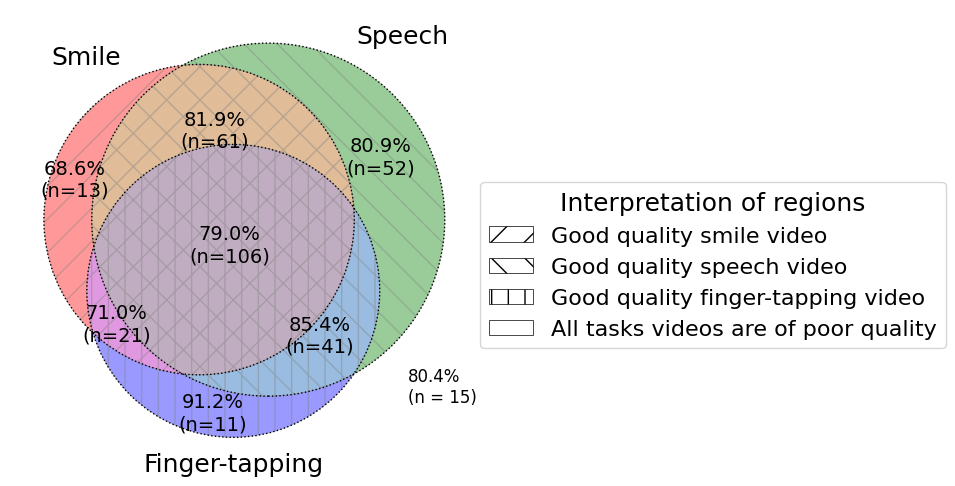

In [15]:
from matplotlib.patches import Patch
def accuracy_to_color(acc):
    if np.isnan(acc):
        return (0.9, 0.9, 1.0)  # very light green for NaN
    intensity = 1.0 - 0.7 * acc
    return (intensity, 1.0, 0.5)

print(f'subsets: {subsets}')
plt.figure(figsize=(10,6))  
v = venn3(subsets=(subsets['100'], subsets['010'], subsets['110'],
                   subsets['001'], subsets['101'], subsets['011'],
                   subsets['111']),
          set_labels=('Smile', 'Speech', 'Finger-tapping'))

c = venn3_circles(subsets=(subsets['100'], subsets['010'], subsets['110'],
                            subsets['001'], subsets['101'], subsets['011'],
                            subsets['111']), linestyle='dotted')

hatch_patterns = {
    '100': '/',     # A only
    '010': '\\',    # B only
    '110': '/\\',   # A & B
    '001': '|',     # C only
    '101': '/|',    # A & C
    '011': '\\|',   # B & C
    '111': '/\\|'   # A & B & C
}

hatch_labels = {
    '000': 'All tasks videos are of poor quality',
    '100': 'Good quality smile video',     # A only
    '010': 'Good quality speech video',    # B only
    '110': 'Smile and speech quality are good, finger quality is poor',   # A & B
    '001': 'Good quality finger-tapping video',     # C only
    '101': 'Smile and finger quality are good, speech quality is poor',    # A & C
    '011': 'Speech and finger quality are good, smile quality is poor',   # B & C
    '111': 'All task videos are of good quality'   # A & B & C
}

# Apply hatches and prepare legend entries
legend_handles = []

# Apply hatching to each subset
for region_id in hatch_patterns.keys():
    patch = v.get_patch_by_id(region_id)
    patch.set_hatch(hatch_patterns[region_id])
    patch.set_edgecolor("gray")  # Optional: for better visibility
    patch.set_linewidth(0.8)
    # Create a legend handle
    if region_id in ['100', '010', '001']:
        legend_handles.append(Patch(facecolor='white', edgecolor='black',
                                    hatch=hatch_patterns[region_id], label=hatch_labels[region_id], linewidth=0.5))

legend_handles.append(Patch(facecolor='white', edgecolor='black', hatch='', label=hatch_labels['000'], linewidth=0.5))

for circle in c:
    circle.set_lw(1.0)
    #circle.set_edgecolor('black')

for region_id in ['100', '010', '110', '001', '101', '011', '111']:
    patch = v.get_patch_by_id(region_id)
    if patch:
        acc = fusion_results[region_id][0]
        #patch.set_color(accuracy_to_color(acc))
        #patch.set_alpha(0.8)
    patch.set_hatch(hatch_patterns[region_id])
    #patch.set_edgecolor("lightgray")  # Optional: for better visibility
    patch.set_linewidth(0.5)
    

for region_id in ['100', '010', '110', '001', '101', '011', '111']:
    label = v.get_label_by_id(region_id)
    if label:
        acc, ci = fusion_results[region_id]
        if not np.isnan(acc):
            label.set_text(f'{acc*100:.1f}%\n(n={subsets[region_id]})')
        else:
            label.set_text('')

# Increase fontsize of region labels (e.g., numbers inside the sets)
for label in v.set_labels:
    if label:
        label.set_fontsize(18)
    
# Increase fontsize of intersecting labels
for label in v.subset_labels:
    if label:
        label.set_fontsize(14)
        #label.set_color('#333333')

acc, ci = fusion_results['000']
outside_text = f'{acc*100:.1f}%\n(n = {subsets["000"]})' if not np.isnan(acc) else 'No Data'
plt.annotate(outside_text, xy=(0.85, 0.15), xycoords='axes fraction', color='black', fontsize=12)
plt.legend(
    handles=legend_handles, 
    title="Interpretation of regions", 
    loc='upper center',       # position at top center
    bbox_to_anchor=(1.5, 0.65),  # shift above plot; adjust y if needed
    ncol=1,                   # number of columns
    fontsize=16,
    title_fontsize=18
)

#plt.tight_layout()
plt.savefig('./plots/figure_5/fusion_accuracy_vs_task_quality.png', dpi=800, bbox_inches='tight')